# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercise 1: Small Quiz

**As stated in the instructions**  
- What is the key difference between traditional machine learning and deep learning?
  1. Key difference between traditional ML and deep learning
Traditional machine learning relies on hand-crafted features selected by domain experts; the algorithm then learns a mapping from those features to the output. Deep learning learns hierarchical representations directly from raw data through multiple layers — it performs both feature extraction and prediction end-to-end. Example: In image classification, a traditional ML pipeline requires a human to design edge or histogram features, while a CNN learns filters at every level automatically.
- How do artificial neural networks mimic the human brain?
2. How ANNs mimic the human brain
Each artificial neuron receives weighted signals from other neurons, sums them, passes the result through an activation function, and forwards the output to the next layer. This mirrors how biological neurons integrate electrochemical signals across synapses and fire when a threshold is exceeded. The learning analogy is Hebbian plasticity — connections that are used together are strengthened, just as weight updates reinforce correct pathways during training.  
- Why does deep learning perform better on large datasets compared to traditional machine learning?
3. Why deep learning performs better on large datasets
Traditional ML models plateau in performance as data grows because their capacity is limited by the chosen features. Deep learning models have millions of parameters and can capture increasingly subtle patterns when trained on more examples — their accuracy keeps improving as dataset size increases, making them ideal for large-scale tasks like speech recognition or image generation.
- What are some challenges of deep learning, and how can they be addressed?
4. Challenges of deep learning and how to address them

Requires large amounts of labelled data → mitigated by transfer learning and data augmentation
High computational cost → addressed with GPUs/TPUs and efficient architectures
Overfitting → controlled with dropout, regularisation, and early stopping
Lack of interpretability → partially addressed with SHAP or Grad-CAM
Vanishing/exploding gradients → handled through weight initialisation, batch normalisation, and ReLU
- What is feature engineering, and why is it not needed in deep learning?
5. Feature engineering and why deep learning doesn't need it
Feature engineering is the manual process of transforming raw data into informative numerical representations — for example, extracting day-of-week from a timestamp. Deep learning eliminates this step because stacked non-linear layers learn task-specific representations automatically: early layers capture low-level patterns (edges, phonemes) and later layers combine them into abstract concepts (objects, words).  
- What role do hidden layers play in a deep learning model?
. Role of hidden layers
Hidden layers learn progressively more abstract transformations of their input, allowing the network to model complex non-linear relationships. Without them, a neural network reduces to logistic regression and can only learn linear decision boundaries. Example: In handwriting recognition, the first hidden layer detects strokes, the second detects curves, and the third combines curves into digit shapes.
- In an artificial neural network, what is the function of an activation function?
7. Function of an activation function
An activation function introduces non-linearity at each neuron. Without it, stacking multiple linear layers would still produce only a linear transformation regardless of depth. Common choices: ReLU (max(0, z)) avoids vanishing gradients and is fast to compute; sigmoid is used in binary output layers; softmax converts outputs into a probability distribution for multi-class problems.

**Guidance**  
Answer in full sentences. Use concise definitions first, then add one concrete example for any two questions to demonstrate understanding.

**To-Do:** Write your answers below.


## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [1]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [2]:
# To-Do: implement weighted_sum then use it to compute the two cases
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    return W_TEMP * temperature_f + W_RAIN * rain01 + BIAS

case1 = (70, 0)   # Temperature=70, Rain=0
case2 = (50, 1)   # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1},
       "case2": {"sum": s2, "decision": y2}})


{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


**To-Do:** Interpret your results. Did the perceptron suggest going outside in both cases? Why or why not? Explain using the threshold rule and the effect of bias.

Written interpretation:
Both cases exceed the threshold of 20, so the perceptron recommends going outside in both. Case 1 gives a weighted sum of 44 (well above 20) because temperature alone contributes 42. Case 2 gives 32.4 — rain reduces the score slightly (only +0.4) but temperature still dominates at 30. The bias of 2.0 acts as a "baseline enthusiasm" that shifts the entire sum upward, making the perceptron easier to activate. Temperature dominates because its weight (0.6) is applied to a large numeric value (50–70), whereas rain is binary (0 or 1) so its contribution is tiny by comparison. Raising the threshold to 35 would change nothing here, but raising it above 44 would make Case 1 also return 0.




## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [3]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [4]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# Hints: use to_categorical
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test,  num_classes=10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)


Labels one-hot: (60000, 10) (10000, 10)


In [5]:
# To-Do:  Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),   # 784 inputs
    layers.Dense(128, activation='relu'),    # hidden layer
    layers.Dense(10,  activation='softmax'), # output layer
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

In [7]:
# To-Do: train then evaluate
history = model.fit(
    x_train, y_train_oh,
    epochs           = 5,
    batch_size       = 64,
    validation_split = 0.1,
    verbose          = 1
)

test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9094 - loss: 0.3201 - val_accuracy: 0.9587 - val_loss: 0.1489
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9585 - loss: 0.1471 - val_accuracy: 0.9663 - val_loss: 0.1196
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9704 - loss: 0.1015 - val_accuracy: 0.9715 - val_loss: 0.0975
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9774 - loss: 0.0769 - val_accuracy: 0.9757 - val_loss: 0.0784
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9816 - loss: 0.0606 - val_accuracy: 0.9788 - val_loss: 0.0751
{'test_loss': 0.07703936845064163, 'test_acc': 0.9779999852180481}


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [8]:
# To-Do: compute forward propagation for the given numbers
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# Weighted sum
z = x1 * w1 + x2 * w2 + b
# z = 1000 + 2.1 + 50000 = 51002.1

# ReLU: max(0, z)
y = max(0, z)

print({"z": z, "prediction": y})


{'z': 51002.1, 'prediction': 51002.1}


**To-Do:** Interpret the result as a house price. Explain the influence of input scaling and bias in full sentences.

Written interpretation:
The model predicts a house price of $51,002.10.
The bias of 50,000 acts as the baseline price — the cost of a house regardless of size or bedrooms, representing fixed costs like land and construction overhead. Without the bias, a house with zero features would be predicted to cost $0, which is unrealistic.
Input scaling matters here: square footage ranges in the thousands while bedroom count is 1–5, so even though both weights are similar (0.5 vs 0.7), the square footage term dominates completely (0.5 × 2000 = 1000 vs 0.7 × 3 = 2.1). In a real model, inputs should be normalised so no feature dominates purely due to its measurement scale.
ReLU ensures the model never predicts a negative price by clamping any negative weighted sum to zero.


## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [9]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


**To-Do:** Explain in full sentences why updating weights using gradient descent reduces the error. Then modify the learning rate or initial weights and describe how this affects learning.

Why gradient descent reduces the error:
The loss function (MSE) measures how far the prediction is from the true value. The gradient tells us which direction to move each weight to increase the loss — so by moving in the opposite direction (subtracting a fraction of the gradient), we take a step downhill on the loss surface. Repeating this reduces the error iteratively.
Concretely: initial prediction = 0.6×4 + 0.3×80 + 10 = 36.4, true = 85, loss = 0.5×(85−36.4)² = 1180.98. The gradient pushes w₁ upward, so next prediction will be larger and closer to 85.
Effect of learning rate:

Too large (0.1): Updates overshoot the minimum → loss oscillates or diverges
Too small (0.0001): Steps are tiny → thousands of iterations needed to converge
Well-tuned (0.01): Converges smoothly in a reasonable number of steps

Effect of initial weights:

All-zero weights cause a symmetry problem in multi-neuron networks — every neuron learns identical gradients and the network fails to specialise
Very large initial weights saturate activations early, making gradients vanish
Small random values (standard initialisation) break symmetry and allow stable learning


## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


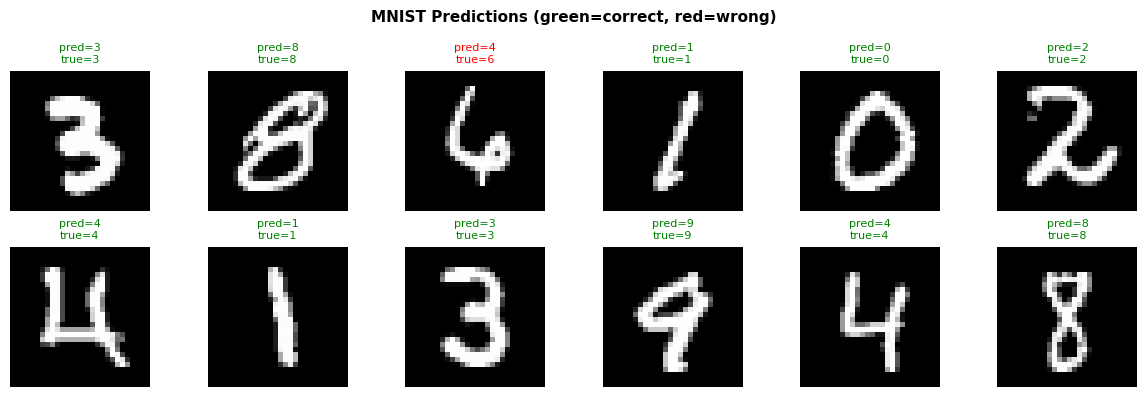

In [10]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

N   = 12
idx = np.random.choice(len(x_test), size=N, replace=False)

x_vis  = x_test[idx]
y_true = y_test[idx]

y_prob = model.predict(x_vis, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cols = 6
rows = int(np.ceil(N / cols))
plt.figure(figsize=(12, 2 * rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    correct = y_pred[i-1] == y_true[i-1]
    color   = "green" if correct else "red"
    plt.title(f"pred={y_pred[i-1]}\ntrue={y_true[i-1]}",
              fontsize=8, color=color)
    plt.axis("off")
plt.suptitle("MNIST Predictions (green=correct, red=wrong)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()